# COMP 9130 | SafeSpace AI Content Moderation
**Author:** Binger Yu  
**Mini Project 9 — Part 1: Data Exploration & Preprocessing**

This notebook covers:
1. Loading and inspecting the dataset
2. Class distribution analysis and imbalance discussion
3. Text length statistics
4. Text cleaning pipeline
5. Visualizations (distribution, word clouds)
6. Stratified train/val/test splits
7. Representative examples per class

## 0. Setup & Imports


In [1]:
# ── Install dependencies ──────────────────────────────────────────────────────
!pip install -q --upgrade transformers fsspec sentence-transformers gcsfs wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompatible.
bigframes 2.37.0 requires gcsfs!=2025.5.0,!=2026.2.0,>=2023.3.0, but you have gcsfs 2026.2.0 which is incompatible.


In [2]:
# ── Mount Google Drive (run once per session) ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Project-wide configuration  ───────────────────────────────────────────────
# Change PROJECT_ROOT to wherever you keep this project in Drive.
PROJECT_ROOT = '/content/drive/My Drive/Colab Notebooks/mini-project-9'

import os
DATA_DIR   = os.path.join(PROJECT_ROOT, 'data')
FIG_DIR    = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

RANDOM_SEED = 42

LABEL_MAP    = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
LABEL_COLORS = {0: '#d62728',     1: '#ff7f0e',            2: '#2ca02c'}

print(f'DATA_DIR : {DATA_DIR}')
print(f'FIG_DIR  : {FIG_DIR}')

DATA_DIR : /content/drive/My Drive/Colab Notebooks/mini-project-9/data
FIG_DIR  : /content/drive/My Drive/Colab Notebooks/mini-project-9/figures


In [4]:
# ── Standard imports ──────────────────────────────────────────────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset
> **Source:** Davidson et al. (2017). *Automated Hate Speech Detection and the Problem of Offensive Language.*  
> Dataset: [Twitter Hate Speech and Offensive Language](https://github.com/t-davidson/hate-speech-and-offensive-language)

In [5]:
# ── Download (cached to Drive on first run) ───────────────────────────────────
import urllib.request

DATA_URL  = ('https://raw.githubusercontent.com/t-davidson/'
             'hate-speech-and-offensive-language/master/data/labeled_data.csv')
DATA_PATH = os.path.join(DATA_DIR, 'labeled_data.csv')

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f'Downloaded → {DATA_PATH}')
else:
    print(f'Already cached: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')

Downloaded → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/labeled_data.csv
Shape   : (24783, 7)
Columns : ['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']


In [6]:
# ── Keep relevant columns; rename tweet → text ────────────────────────────────
df = df[['count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']].copy()
df.rename(columns={'tweet': 'text'}, inplace=True)

print(f'Total samples : {len(df)}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nClass value counts:')
print(df['class'].value_counts().sort_index())

df.head()

Total samples : 24783
Missing values:
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
text                  0
dtype: int64

Class value counts:
class
0     1430
1    19190
2     4163
Name: count, dtype: int64


,count,hate_speech,offensive_language,neither,class,text
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## 2. Class Distribution Analysis

**Key finding:** The dataset is severely imbalanced — ~5% hate speech, ~77% offensive language, ~18% neither.

**Why this matters:** A naïve model that always predicts *Offensive Language* achieves **77% accuracy** but has 0% recall on hate speech — the most legally and ethically critical class. **Per-class F1 is the right metric**, not accuracy.

In [7]:
# ── Class distribution statistics ─────────────────────────────────────────────
n_classes    = df['class'].nunique()                    # derived, not hardcoded
class_counts = df['class'].value_counts().sort_index()
class_pcts   = class_counts / len(df) * 100

print('=' * 58)
print('CLASS DISTRIBUTION')
print('=' * 58)
for cls_id in range(n_classes):
    print(f'  Class {cls_id} ({LABEL_MAP[cls_id]:20s}): '
          f'{class_counts[cls_id]:5,d}  ({class_pcts[cls_id]:.1f}%)')
print(f'  {"TOTAL":30s}: {len(df):5,d}  (100.0%)')

majority_pct = class_pcts.max()
print(f'\n  ⚠ Imbalance Impact:')
print(f'  1. Always-majority baseline → {majority_pct:.0f}% accuracy (misleading!)')
print( '  2. Hate speech has ~1,400 samples — model may never learn it')
print( '  3. Mitigation: class_weight="balanced" (sklearn) | weighted CrossEntropyLoss (PyTorch)')
print( '  4. Evaluation metric: per-class F1, NOT overall accuracy')

CLASS DISTRIBUTION
  Class 0 (Hate Speech         ): 1,430  (5.8%)
  Class 1 (Offensive Language  ): 19,190  (77.4%)
  Class 2 (Neither             ): 4,163  (16.8%)
  TOTAL                         : 24,783  (100.0%)

  ⚠ Imbalance Impact:
  1. Always-majority baseline → 77% accuracy (misleading!)
  2. Hate speech has ~1,400 samples — model may never learn it
  3. Mitigation: class_weight="balanced" (sklearn) | weighted CrossEntropyLoss (PyTorch)
  4. Evaluation metric: per-class F1, NOT overall accuracy


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/class_distribution.png


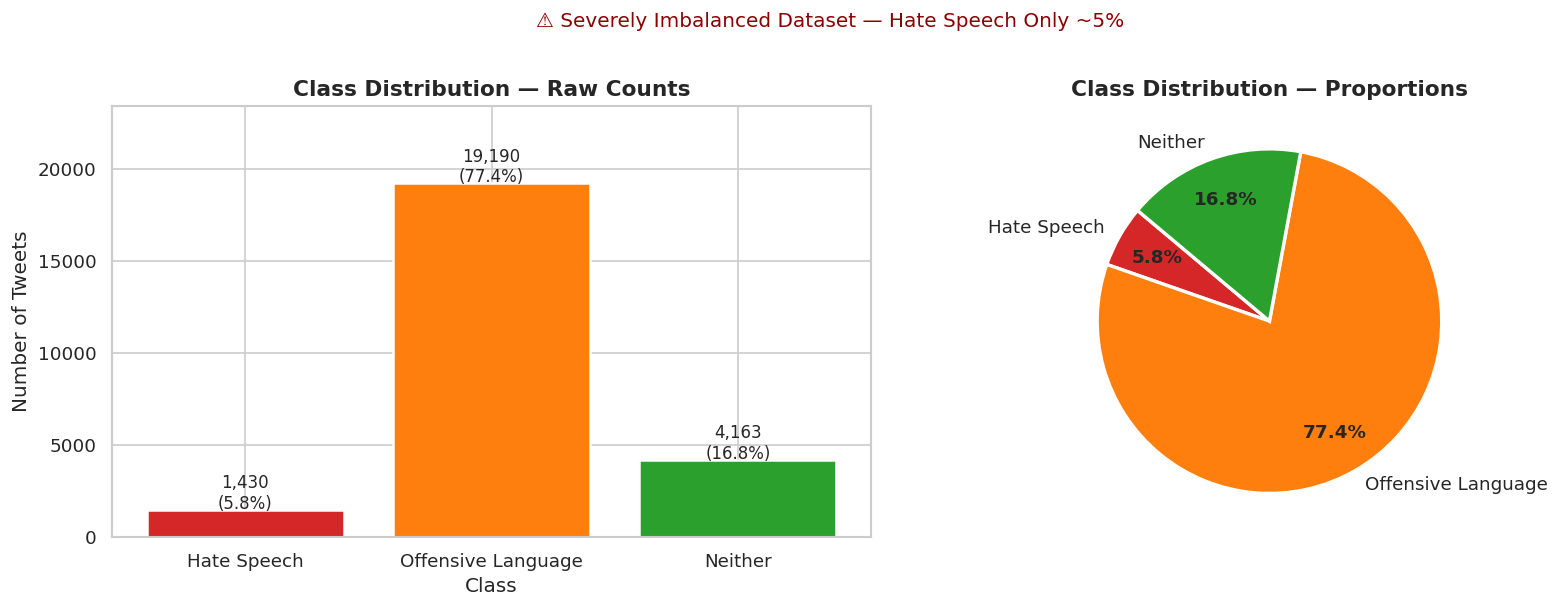

In [8]:
# ── Visualise class imbalance ─────────────────────────────────────────────────
colors = [LABEL_COLORS[i] for i in range(n_classes)]
labels = [LABEL_MAP[i]    for i in range(n_classes)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(labels, class_counts.values, color=colors,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].set_xlabel('Class')
for bar, cnt, pct in zip(bars, class_counts.values, class_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylim(0, class_counts.max() * 1.22)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportions', fontsize=13, fontweight='bold')

plt.suptitle('⚠ Severely Imbalanced Dataset — Hate Speech Only ~5%',
             fontsize=12, color='darkred', y=1.01)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'class_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 3. Text Length Statistics

In [9]:
# ── Compute char and word lengths ─────────────────────────────────────────────
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

print('=== Overall Text Length (raw tweets) ===')
print(df[['char_len', 'word_len']].describe().round(1))

print('\n=== Word Length by Class ===')
for cls_id in range(n_classes):
    s = df[df['class'] == cls_id]['word_len']
    print(f'  {LABEL_MAP[cls_id]:22s}: '
          f'mean={s.mean():.1f}  median={s.median():.0f}  '
          f'min={s.min()}  max={s.max()}')

=== Overall Text Length (raw tweets) ===
       char_len  word_len
count   24783.0   24783.0
mean       85.4      14.1
std        41.5       6.8
min         5.0       1.0
25%        52.0       9.0
50%        81.0      13.0
75%       119.0      19.0
max       754.0      52.0

=== Word Length by Class ===
  Hate Speech           : mean=13.9  median=14  min=1  max=32
  Offensive Language    : mean=14.0  median=13  min=1  max=36
  Neither               : mean=14.9  median=15  min=1  max=52


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/length_distribution.png


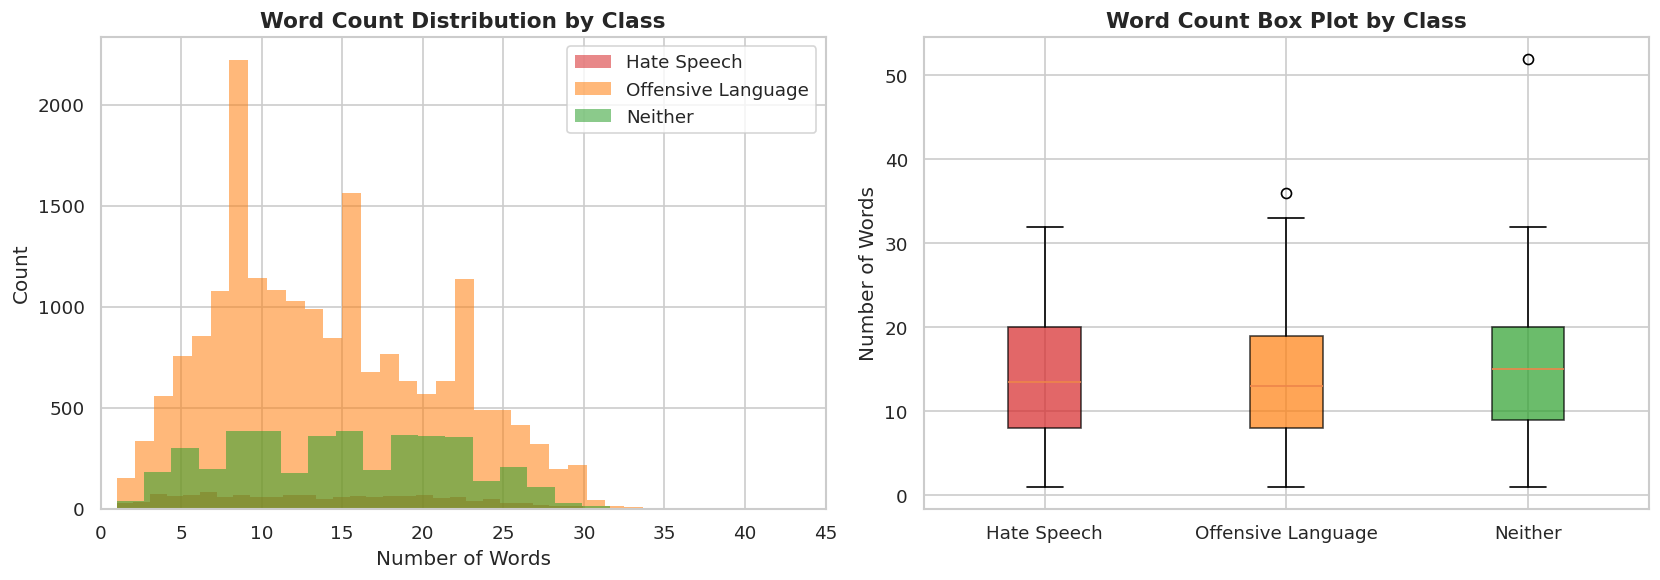

In [10]:
# ── Visualise length distributions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls_id in range(n_classes):
    axes[0].hist(df[df['class'] == cls_id]['word_len'],
                 bins=30, alpha=0.55, color=LABEL_COLORS[cls_id],
                 label=LABEL_MAP[cls_id], edgecolor='none')

axes[0].set_title('Word Count Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 45)

bp = axes[1].boxplot(
    [df[df['class'] == i]['word_len'].values for i in range(n_classes)],
    patch_artist=True, tick_labels=labels   # tick_labels avoids the deprecation warning
)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_title('Word Count Box Plot by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Words')

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'length_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 4. Text Cleaning Pipeline

Tweets are noisy: URLs, @mentions, hashtags, HTML entities, numbers, and special characters. We normalise all of these before feature extraction.

**Design choices:**
- URLs removed entirely — no content signal.
- @mentions removed — privacy + no predictive value.
- Hashtags: `#` stripped but word kept (e.g. `#racist → racist`) — the word carries signal.
- Lowercase — reduces vocabulary size for TF-IDF.
- *Note:* For transformers (Part 3), DistilBERT tolerates more noise, but we use the same cleaned text for a fair comparison.

In [11]:
# ── Text cleaning function ────────────────────────────────────────────────────
def clean_tweet(text: str) -> str:
    """Normalise a raw tweet for NLP processing.

    Steps:
      1. Lowercase
      2. Remove URLs (http/https/www)
      3. Remove @mentions
      4. Remove RT marker
      5. Hashtags: drop '#', keep word
      6. Remove HTML entities (&amp; etc.)
      7. Remove non-alphabetic characters
      8. Collapse whitespace
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'\brt\b', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_tweet)

print('=== Cleaning Demonstration ===')
for i in [0, 5, 200]:
    print(f'  RAW:     {df["text"].iloc[i][:110]}')
    print(f'  CLEANED: {df["text_clean"].iloc[i][:110]}')
    print()

=== Cleaning Demonstration ===
  RAW:     !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you shoul
  CLEANED: as a woman you shouldn t complain about cleaning up your house as a man you should always take the trash out

  RAW:     !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody but still
  CLEANED: the shit just blows me claim you so faithful and down for somebody but still fucking with hoes

  RAW:     "@NewsomeJade: I ain't never seen a bitch so obsessed with they nigga&#128514;" I'm obsessed with mine &#12852
  CLEANED: i ain t never seen a bitch so obsessed with they nigga i m obsessed with mine



In [12]:
# ── Drop rows that became empty after cleaning ────────────────────────────────
empty_mask = df['text_clean'].str.strip() == ''
print(f'Empty after cleaning: {empty_mask.sum()}')
df = df[~empty_mask].reset_index(drop=True)

df['word_len_clean'] = df['text_clean'].str.split().str.len()
print(f'Remaining samples: {len(df)}')
print(df['word_len_clean'].describe().round(1))

Empty after cleaning: 2
Remaining samples: 24781
count    24781.0
mean        13.0
std          6.9
min          1.0
25%          7.0
50%         12.0
75%         18.0
max         34.0
Name: word_len_clean, dtype: float64


## 5. Word Cloud Visualization by Class
> ⚠ **Content Warning:** Word clouds reflect raw training data content.

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/wordclouds.png


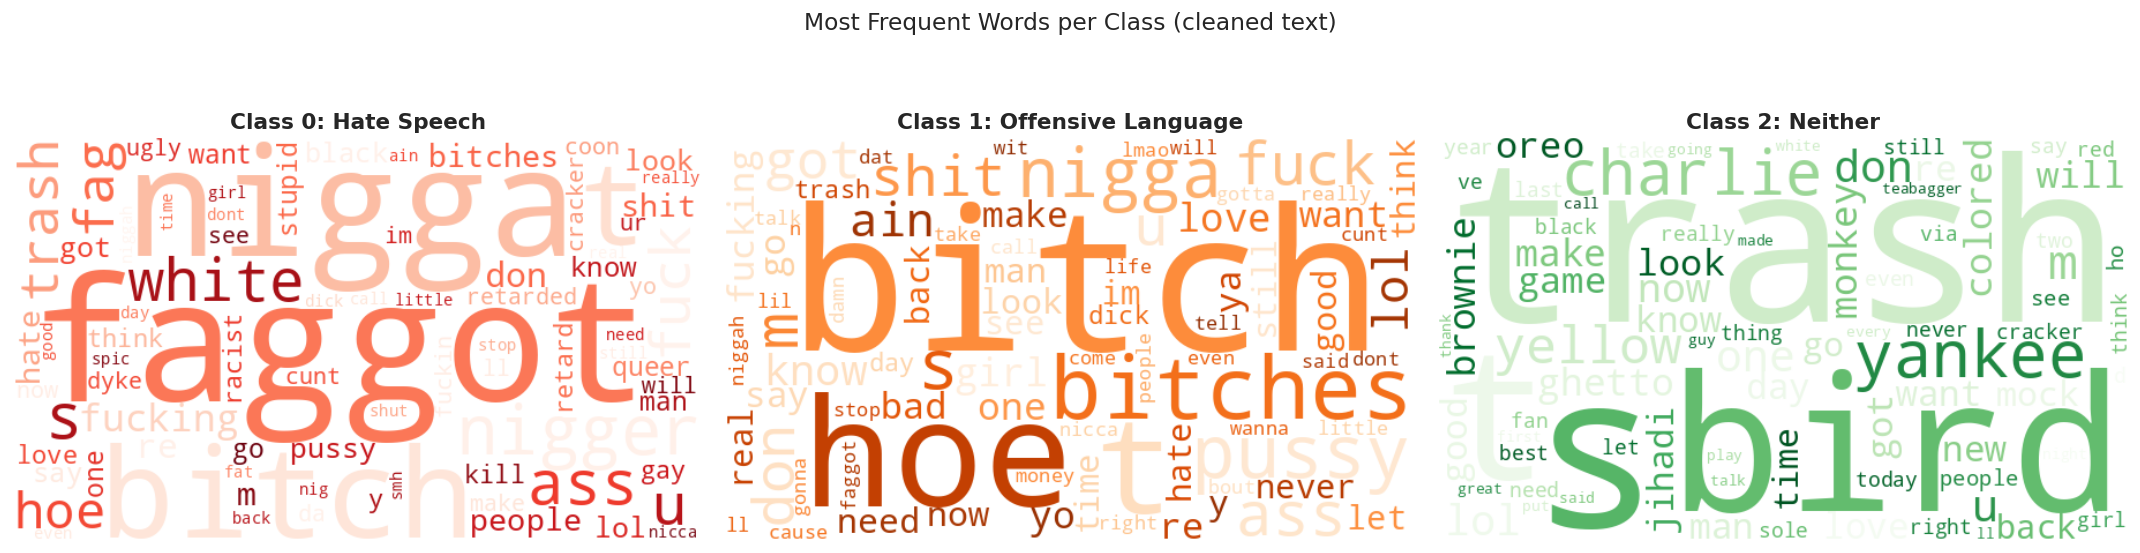

In [13]:
# ── Word clouds ───────────────────────────────────────────────────────────────
cmaps = ['Reds', 'Oranges', 'Greens']
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5))

for cls_id in range(n_classes):
    corpus = ' '.join(df[df['class'] == cls_id]['text_clean'])
    wc = WordCloud(
        width=600, height=350, background_color='white',
        colormap=cmaps[cls_id], max_words=80, collocations=False
    ).generate(corpus)
    axes[cls_id].imshow(wc, interpolation='bilinear')
    axes[cls_id].set_title(f'Class {cls_id}: {LABEL_MAP[cls_id]}',
                            fontsize=13, fontweight='bold')
    axes[cls_id].axis('off')

plt.suptitle('Most Frequent Words per Class (cleaned text)', fontsize=14, y=1.01)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'wordclouds.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

## 6. Representative Examples per Class

> ⚠ **Content Warning:** Examples contain offensive and hateful language — necessary for understanding the labeling nuance.

The critical challenge: distinguishing **hate speech** (attacks a protected group) from **offensive language** (rude/vulgar but not group-targeted).

In [14]:
# ── Representative examples ───────────────────────────────────────────────────
N_EXAMPLES = 4
label_cols = ['hate_speech', 'offensive_language', 'neither']

print('=' * 70)
print('REPRESENTATIVE EXAMPLES PER CLASS')
print('   ⚠ Content Warning: offensive/hateful language present')
print('=' * 70)

for cls_id in range(n_classes):
    subset    = df[df['class'] == cls_id].sample(N_EXAMPLES, random_state=RANDOM_SEED)
    label_col = label_cols[cls_id]
    print(f"\n{'─'*70}")
    print(f"  CLASS {cls_id}: {LABEL_MAP[cls_id].upper()}")
    print(f"{'─'*70}")
    for _, row in subset.iterrows():
        agreement = row[label_col] / row['count'] * 100
        print(f"  [Annotator agreement: {agreement:.0f}%  ({row[label_col]:.0f}/{row['count']:.0f} raters)]")
        print(f"  RAW:     {str(row['text'])[:100]}")
        print(f"  CLEANED: {row['text_clean'][:100]}")
        print()

print('\n  Key Nuances Observed:')
print('  - Hate speech TARGETS a protected group (race, religion, gender, sexuality).')
print('  - Offensive language uses profanity/vulgarity without group targeting.')
print('  - Annotation disagreement is common — this task is hard even for humans.')
print('  - Context (sarcasm, slang) makes automatic classification especially challenging.')

REPRESENTATIVE EXAMPLES PER CLASS
   ⚠ Content Warning: offensive/hateful language present

──────────────────────────────────────────────────────────────────────
  CLASS 0: HATE SPEECH
──────────────────────────────────────────────────────────────────────
  [Annotator agreement: 67%  (2/3 raters)]
  RAW:     @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag
  CLEANED: i do not like talking to you faggot and i did but in a nicely way fag

  [Annotator agreement: 67%  (2/3 raters)]
  RAW:     RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.W
  CLEANED: what straight guys take a picture of themselves naked in a hot tun what fags

  [Annotator agreement: 56%  (5/9 raters)]
  RAW:     @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"
  CLEANED: america today the rule of thumb is when in doubt blame whitey

  [Annotator agreement: 67%  (2/3 raters)]
  RAW:     @S

## 7. Stratified Train / Val / Test Split

**Split:** 70% train | 15% val | 15% test  
**Stratified:** ensures the rare hate speech class (~5%) is proportionally represented in every split.

In [15]:
# ── Stratified 70 / 15 / 15 split ─────────────────────────────────────────────
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

X = df['text_clean'].values
y = df['class'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),   # 0.5 of temp
    random_state=RANDOM_SEED, stratify=y_temp
)

print('=== Split Sizes ===')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:6s}: {len(arr):5,d} ({len(arr)/len(df)*100:.1f}%)')

print('\n=== Class Ratios Preserved? ===')
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts    = pd.Series(y_split).value_counts(normalize=True).sort_index()
    ratio_str = '  '.join([f'{LABEL_MAP[i]}: {v:.1%}' for i, v in counts.items()])
    print(f'  {name:6s}: {ratio_str}')

print('\n  ✅ Stratification confirmed — hate speech ~5% in every split.')

=== Split Sizes ===
  Train : 17,346 (70.0%)
  Val   : 3,717 (15.0%)
  Test  : 3,718 (15.0%)

=== Class Ratios Preserved? ===
  Train : Hate Speech: 5.8%  Offensive Language: 77.4%  Neither: 16.8%
  Val   : Hate Speech: 5.8%  Offensive Language: 77.4%  Neither: 16.8%
  Test  : Hate Speech: 5.8%  Offensive Language: 77.4%  Neither: 16.8%

  ✅ Stratification confirmed — hate speech ~5% in every split.


Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/figures/split_distribution.png


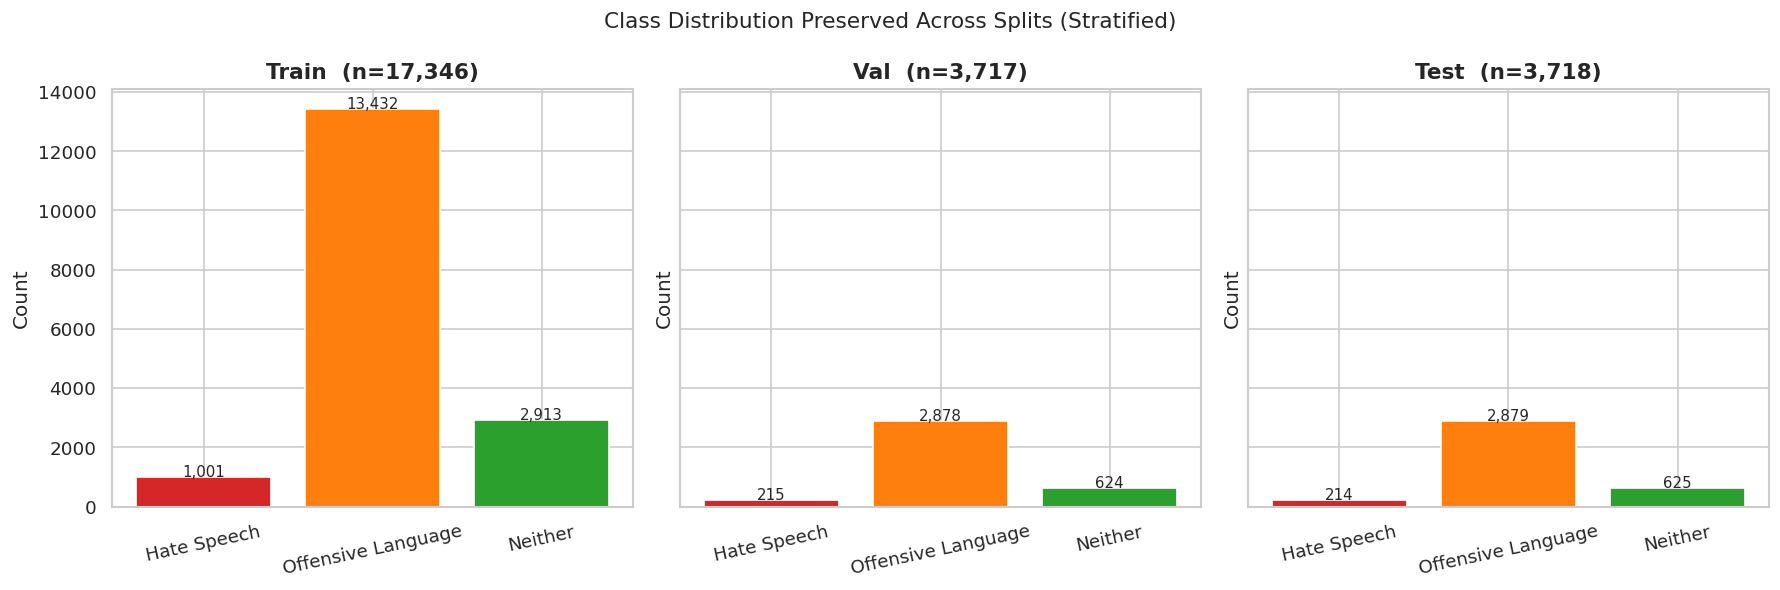

In [16]:
# ── Visualise split class distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
splits = [('Train', y_train), ('Val', y_val), ('Test', y_test)]

for ax, (split_name, y_split) in zip(axes, splits):
    cnts = pd.Series(y_split).value_counts().sort_index()
    bars = ax.bar(labels, cnts.values, color=colors, edgecolor='white')
    ax.set_title(f'{split_name}  (n={len(y_split):,})', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=12)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{cnt:,}', ha='center', fontsize=9)

plt.suptitle('Class Distribution Preserved Across Splits (Stratified)', fontsize=13)
plt.tight_layout()

save_path = os.path.join(FIG_DIR, 'split_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved → {save_path}')
plt.show()

In [17]:
# ── Save splits to Drive (used by 02_baseline and 03_transformer) ─────────────
split_data = {
    'train': (X_train, y_train),
    'val'  : (X_val,   y_val  ),
    'test' : (X_test,  y_test ),
}
for split_name, (X_split, y_split) in split_data.items():
    path = os.path.join(DATA_DIR, f'{split_name}.csv')
    pd.DataFrame({'text': X_split, 'label': y_split}).to_csv(path, index=False)
    print(f'Saved → {path}')

Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/train.csv
Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/val.csv
Saved → /content/drive/My Drive/Colab Notebooks/mini-project-9/data/test.csv


## 8. Summary

In [18]:
# ── Summary table (all values derived — no hardcoding) ────────────────────────
summary = {
    'Total samples'                    : len(df),
    'Class 0 — Hate Speech'            : f"{class_pcts[0]:.1f}%",
    'Class 1 — Offensive Language'     : f"{class_pcts[1]:.1f}%",
    'Class 2 — Neither'                : f"{class_pcts[2]:.1f}%",
    'Avg tweet length (words, raw)'    : f"{df['word_len'].mean():.1f}",
    'Avg tweet length (words, cleaned)': f"{df['word_len_clean'].mean():.1f}",
    'Train / Val / Test split'         : f'{100*(1-VAL_RATIO-TEST_RATIO):.0f}% / '
                                         f'{100*VAL_RATIO:.0f}% / '
                                         f'{100*TEST_RATIO:.0f}% (stratified)',
}
summary_df = pd.DataFrame(summary.items(), columns=['Property', 'Value'])
print(summary_df.to_string(index=False))

print('\nPreprocessing decisions:')
print('  - URLs, @mentions, RT removed — not class-predictive.')
print('  - Hashtag word preserved — may carry semantic signal.')
print('  - Lowercase + alpha-only — reduces TF-IDF vocabulary noise.')
print('  - Stratified splits — preserve the 5% hate class in every fold.')
print('\nClass imbalance mitigation (applied in Parts 2 & 3):')
print('  - class_weight="balanced" in sklearn classifiers (Part 2)')
print('  - Weighted CrossEntropyLoss with inverse-frequency weights (Part 3)')

                         Property                        Value
                    Total samples                        24781
            Class 0 — Hate Speech                         5.8%
     Class 1 — Offensive Language                        77.4%
                Class 2 — Neither                        16.8%
    Avg tweet length (words, raw)                         14.1
Avg tweet length (words, cleaned)                         13.0
         Train / Val / Test split 70% / 15% / 15% (stratified)

Preprocessing decisions:
  - URLs, @mentions, RT removed — not class-predictive.
  - Hashtag word preserved — may carry semantic signal.
  - Lowercase + alpha-only — reduces TF-IDF vocabulary noise.
  - Stratified splits — preserve the 5% hate class in every fold.

Class imbalance mitigation (applied in Parts 2 & 3):
  - class_weight="balanced" in sklearn classifiers (Part 2)
  - Weighted CrossEntropyLoss with inverse-frequency weights (Part 3)
